In [23]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [24]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [25]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,3.597487,-2.401459,-0.623487,-1.668582,-2.675658,1
1,-0.212726,-0.737594,0.811863,-0.928889,-1.277573,0
2,1.814061,2.875571,2.352543,-1.014222,1.100726,1
3,0.309413,-0.518414,1.300665,-0.686908,-1.402447,0
4,-0.104901,-1.291291,2.377375,0.057622,-0.537920,0


In [26]:
# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [27]:
# function for feature sampling
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [28]:
# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [29]:
df1 = combined_sampling(df,0.5,0.5)

In [30]:
df2 = combined_sampling(df,0.5,0.5)

In [31]:
df3 = combined_sampling(df,0.5,0.5)

In [32]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col2', 'col1', 'target'], dtype='str')
Index(['col1', 'col4', 'target'], dtype='str')
Index(['col3', 'col5', 'target'], dtype='str')


In [33]:
df3

,col3,col5,target
18,0.477695,-3.028291,0
33,1.096323,-0.225825,1
87,1.258665,0.759437,0
86,0.023106,-0.842280,0
54,1.291840,-3.823230,0
8,-0.072164,-2.452268,0
27,1.606043,-0.947518,0
63,1.300381,-0.003197,0
88,1.201796,-1.169233,1
72,1.114265,-0.340537,1


In [34]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [35]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [36]:
from sklearn.tree import plot_tree

[Text(0.6666666666666666, 0.9, 'x[0] <= 0.107\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.5555555555555556, 0.7, 'x[1] <= 0.88\ngini = 0.334\nsamples = 33\nvalue = [26, 7]'),
 Text(0.6111111111111112, 0.8, 'True  '),
 Text(0.3333333333333333, 0.5, 'x[0] <= -1.364\ngini = 0.074\nsamples = 26\nvalue = [25, 1]'),
 Text(0.2222222222222222, 0.3, 'x[0] <= -1.459\ngini = 0.219\nsamples = 8\nvalue = [7, 1]'),
 Text(0.1111111111111111, 0.1, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.3333333333333333, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.4444444444444444, 0.3, 'gini = 0.0\nsamples = 18\nvalue = [18, 0]'),
 Text(0.7777777777777778, 0.5, 'x[0] <= -0.988\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.6666666666666666, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8888888888888888, 0.3, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.7777777777777778, 0.7, 'gini = 0.0\nsamples = 17\nvalue = [0, 17]'),
 Text(0.7222222222222222, 0.8, '  F

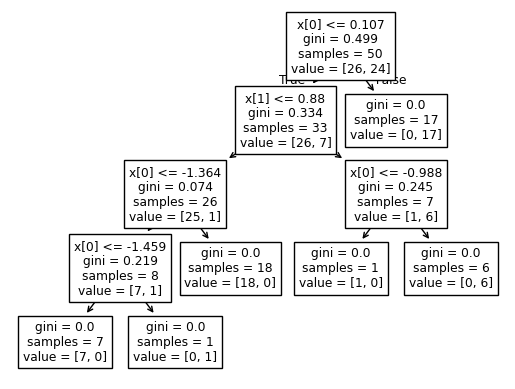

In [37]:
plot_tree(clf1)

[Text(0.45454545454545453, 0.9545454545454546, 'x[0] <= 0.235\ngini = 0.497\nsamples = 50\nvalue = [27, 23]'),
 Text(0.36363636363636365, 0.8636363636363636, 'x[1] <= -1.543\ngini = 0.375\nsamples = 36\nvalue = [27, 9]'),
 Text(0.40909090909090906, 0.9090909090909092, 'True  '),
 Text(0.18181818181818182, 0.7727272727272727, 'x[0] <= -0.892\ngini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.09090909090909091, 0.6818181818181818, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.2727272727272727, 0.6818181818181818, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.5454545454545454, 0.7727272727272727, 'x[0] <= -2.988\ngini = 0.312\nsamples = 31\nvalue = [25, 6]'),
 Text(0.45454545454545453, 0.6818181818181818, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.6363636363636364, 0.6818181818181818, 'x[0] <= -2.053\ngini = 0.278\nsamples = 30\nvalue = [25, 5]'),
 Text(0.5454545454545454, 0.5909090909090909, 'gini = 0.0\nsamples = 8\nvalue = [8, 0]'),
 Text(0.7272727272727273, 0.59

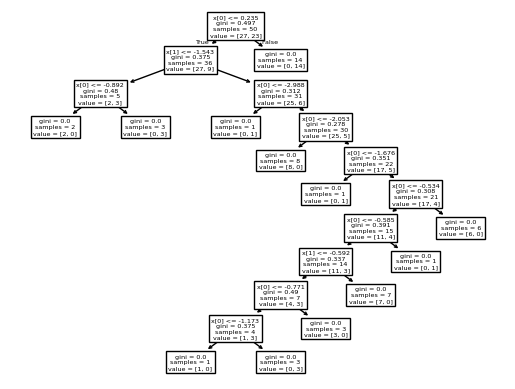

In [38]:
plot_tree(clf2)

[Text(0.4230769230769231, 0.9285714285714286, 'x[1] <= -1.903\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.15384615384615385, 0.7857142857142857, 'x[1] <= -3.02\ngini = 0.18\nsamples = 10\nvalue = [9, 1]'),
 Text(0.28846153846153844, 0.8571428571428572, 'True  '),
 Text(0.07692307692307693, 0.6428571428571429, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.23076923076923078, 0.6428571428571429, 'x[1] <= -2.732\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.15384615384615385, 0.5, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3076923076923077, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.6923076923076923, 0.7857142857142857, 'x[0] <= 1.704\ngini = 0.469\nsamples = 40\nvalue = [15, 25]'),
 Text(0.5576923076923077, 0.8571428571428572, '  False'),
 Text(0.5384615384615384, 0.6428571428571429, 'x[0] <= 1.238\ngini = 0.498\nsamples = 30\nvalue = [14, 16]'),
 Text(0.46153846153846156, 0.5, 'x[1] <= -0.933\ngini = 0.444\nsamples = 24\nvalue = [8, 16]')

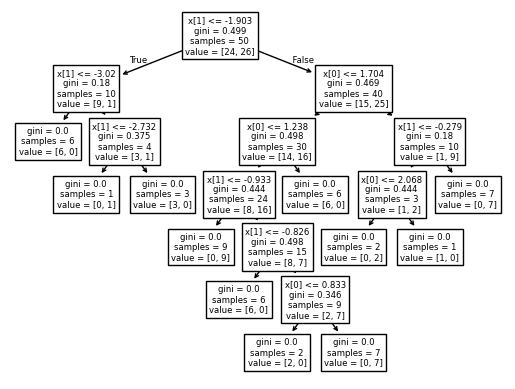

In [39]:
plot_tree(clf3)

In [40]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

d:\RANDOM_FOREST\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [41]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

d:\RANDOM_FOREST\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [42]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

d:\RANDOM_FOREST\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [43]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
66,-1.270888,-1.124012,1.395680,-1.182455,-1.295553,0
10,-0.611128,-1.605369,0.947321,-0.785424,1.552261,0
53,0.191087,-0.947817,0.555541,-0.807358,-0.081322,0
23,0.763023,2.974226,1.786381,-0.990963,0.364459,1
68,-1.446623,-1.658530,2.022296,-0.295675,-0.247069,0
94,0.228380,1.078196,1.810605,-1.798408,-0.387354,1
23,0.763023,2.974226,1.786381,-0.990963,0.364459,1
14,-1.376183,-1.168955,1.230054,-0.340748,0.221932,0
83,2.249052,0.072422,0.709929,-2.924048,-1.164097,1
94,0.228380,1.078196,1.810605,-1.798408,-0.387354,1
